### Algorithm Evaluation

### Build a model that can predict Loan Approval status based on

### Business Objective: Build a model that can predict the status of Loan Approval on basis of many intermediate factors.

### Data Gathering

In [1]:
import pandas as pd
df = pd.read_csv(r"https://raw.githubusercontent.com/kavaderohan2005-netizen/Datasets/refs/heads/main/train_loan.csv")
df.head()

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0


### Perform basic data quality checks

In [2]:
df.shape

(58645, 13)

In [3]:
df.columns

Index(['id', 'person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'loan_status'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

### Separate X and Y Features

    Y : Loan Status

    0-> Not Approved
    1-> Approved

In [5]:
X = df.drop(columns=['id','loan_status'])
Y = df[['loan_status']]

display(X.head())
print('--------------')
display(Y.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14
1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2
2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10
3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5
4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3


--------------


,loan_status
0,0
1,0
2,0
3,0
4,0


### Observe whether Y data is balanced or not.

**Meaning:** DO we have moderate datapoints for Class approved and Not approved(0,1)

In [6]:
Y['loan_status'].value_counts()

loan_status
0    50295
1     8350
Name: count, dtype: int64

In [7]:
((Y['loan_status'].value_counts())/(len(df)))*100

loan_status
0    85.761787
1    14.238213
Name: count, dtype: float64

<Axes: ylabel='loan_status'>

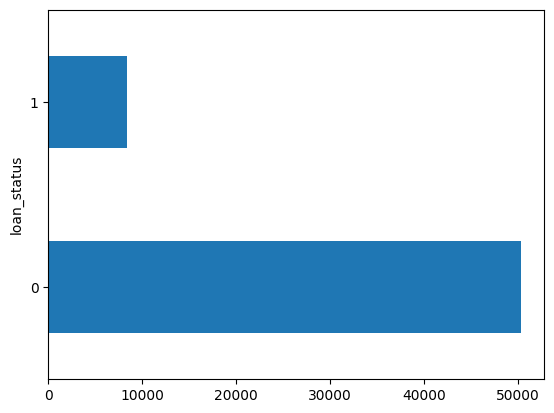

In [8]:
Y['loan_status'].value_counts().plot(kind='barh')

### The dataset is imbalanced in nature

**Technique 1:** splitting the data on basis of stratified split

In [9]:
from sklearn.model_selection import train_test_split
xtrain1,xtest1,ytrain1,ytest1 = train_test_split(X,Y,train_size=0.75,stratify=Y)

In [10]:
xtrain1.shape

(43983, 11)

In [11]:
ytrain1.shape

(43983, 1)

In [12]:
xtrain1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
5972,41,30000,RENT,0.0,MEDICAL,B,10000,10.71,0.33,N,11
926,32,40000,MORTGAGE,1.0,EDUCATION,A,10000,5.79,0.25,N,10
23345,35,140000,OWN,0.0,EDUCATION,C,16000,15.96,0.11,Y,9
48307,27,60000,MORTGAGE,11.0,HOMEIMPROVEMENT,A,6000,6.62,0.10,N,9
20423,24,30000,RENT,1.0,VENTURE,B,7000,10.99,0.23,N,4


In [13]:

xtest1.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
47063,26,50000,MORTGAGE,6.0,EDUCATION,C,8000,12.99,0.16,Y,4
36153,23,73000,RENT,7.0,DEBTCONSOLIDATION,C,2500,14.35,0.03,N,3
19201,24,45000,RENT,2.0,VENTURE,C,6000,12.99,0.13,N,2
36668,28,46000,RENT,5.0,MEDICAL,C,20000,14.27,0.43,N,5
15642,25,50000,RENT,3.0,VENTURE,A,8000,5.42,0.16,N,4


### Data Preprocessing and Data Cleaning

In [14]:
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

cat = list(X.select_dtypes(include='object').columns) 
con = list(X.select_dtypes(include='number').columns)

num_pipe = make_pipeline(SimpleImputer(strategy='median'),
                         StandardScaler())

cat_pipe = make_pipeline(SimpleImputer(strategy='most_frequent'),
                         OneHotEncoder(handle_unknown='ignore',sparse_output=False))

pre = ColumnTransformer([('cat',cat_pipe,cat),
                         ('con',num_pipe,con)]).set_output(transform='pandas')

pre

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [15]:
pre.fit(xtrain1)

,transformers,"[('cat', ...), ('con', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,missing_values,nan
,strategy,'most_frequent'
,fill_value,None


In [16]:
xtrain1_pre = pre.transform(xtrain1)
xtest1_pre = pre.transform(xtest1)

In [17]:
xtrain1_pre.head(2)

,cat__person_home_ownership_MORTGAGE,cat__person_home_ownership_OTHER,cat__person_home_ownership_OWN,cat__person_home_ownership_RENT,cat__loan_intent_DEBTCONSOLIDATION,cat__loan_intent_EDUCATION,cat__loan_intent_HOMEIMPROVEMENT,cat__loan_intent_MEDICAL,cat__loan_intent_PERSONAL,cat__loan_intent_VENTURE,...,cat__loan_grade_G,cat__cb_person_default_on_file_N,cat__cb_person_default_on_file_Y,con__person_age,con__person_income,con__person_emp_length,con__loan_amnt,con__loan_int_rate,con__loan_percent_income,con__cb_person_cred_hist_length
5972,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,2.231321,-0.892527,-1.191199,0.141939,0.012279,1.861147,1.289064
926,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.738162,-0.630523,-0.937492,0.141939,-1.611195,0.989207,1.040641


### Model Building

### Resampling Method

In [18]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.


### Restart the kernel and run all the cells

**Resampling:**

1. Over sampling -> SMOTE , ADASYN SMOTE: Synthetic Minority Over sampling technique ADASYN : Adaptive Synthetic sample technique
2. Under sampling

In [19]:
len(xtrain1_pre)

43983

In [20]:
ytrain1['loan_status'].value_counts()

loan_status
0    37721
1     6262
Name: count, dtype: int64

In [21]:
from imblearn.over_sampling import SMOTE,ADASYN

smote = SMOTE()

x_sampl,y_sampl = smote.fit_resample(xtrain1_pre,ytrain1)

In [22]:
len(x_sampl)

75442

In [23]:
len(y_sampl)

75442

In [24]:
y_sampl['loan_status'].value_counts()

loan_status
1    37721
0    37721
Name: count, dtype: int64

### Algorithm Evaluation

In [25]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score

In [27]:
dct = {
    'Logistic' : LogisticRegression(),
    'DecisionTree': DecisionTreeClassifier(),
    'RandomForest' : RandomForestClassifier(),
    'GradientBoosting' : GradientBoostingClassifier(),
    'XGBoost' : XGBClassifier()
}

In [28]:
dct.items()

dict_items([('Logistic', LogisticRegression()), ('DecisionTree', DecisionTreeClassifier()), ('RandomForest', RandomForestClassifier()), ('GradientBoosting', GradientBoostingClassifier()), ('XGBoost', XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...))])

In [29]:
f1_scores = []

for name,model in dct.items(): # key value pairs
    # Fit the model
    model.fit(x_sampl,y_sampl['loan_status'])
    # Predict the results
    ypred_test = model.predict(xtest1_pre)
    f1 = f1_score(ytest1,ypred_test)
    f1_scores.append(round(f1,2))

print(f1_scores)

[0.6, 0.67, 0.8, 0.76, 0.81]


In [30]:
res = {
    'Name':list(dct.keys()),
    'F1_score': f1_scores
}
df_res = pd.DataFrame(res)
df_res.sort_values(by='F1_score',ascending=False)

,Name,F1_score
4,XGBoost,0.81
2,RandomForest,0.80
3,GradientBoosting,0.76
1,DecisionTree,0.67
0,Logistic,0.60


### We are finalising XGBoost as the best model for deployment

### Hyperparameter tuning


### XGBoost: n_estimators

In [31]:
from xgboost import XGBClassifier

model = XGBClassifier(n_estimators=100,
                      max_depth=5)
model.fit(x_sampl,y_sampl)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
model.score(x_sampl,y_sampl)

0.9721905569841732

In [33]:
model.score(xtest1_pre,ytest1)

0.9523257400081844

In [34]:
params = {
    'n_estimators':[50,100],
    'max_depth':[4,5]
}

base_model = XGBClassifier()

from sklearn.model_selection import GridSearchCV
gscv = GridSearchCV(estimator=base_model,cv=3,param_grid=params,scoring='f1_macro')
gscv.fit(x_sampl,y_sampl)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'max_depth': [4, 5], 'n_estimators': [50, 100]}"
,scoring,'f1_macro'
,n_jobs,None
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [35]:
gscv.best_params_

{'max_depth': 5, 'n_estimators': 100}

In [36]:
gscv.best_score_

np.float64(0.9532795409690374)

In [37]:
    best_xgboost = gscv.best_estimator_
best_xgboost

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [38]:
best_xgboost.score(x_sampl,y_sampl)

0.9721905569841732

In [39]:
best_xgboost.score(xtest1_pre,ytest1)

0.9523257400081844

### Evaluation Metrics

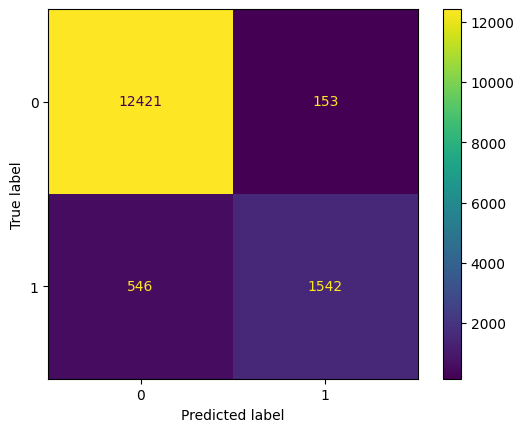

In [40]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
ConfusionMatrixDisplay.from_estimator(best_xgboost,xtest1_pre,ytest1)

In [41]:
ypreds = best_xgboost.predict(xtest1_pre)
print(classification_report(ytest1,ypreds))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97     12574
           1       0.91      0.74      0.82      2088

    accuracy                           0.95     14662
   macro avg       0.93      0.86      0.89     14662
weighted avg       0.95      0.95      0.95     14662



In [42]:
from sklearn.metrics import roc_curve,auc

fpr,tpr,thresholds = roc_curve(ytest1,ypreds)

auc_scores = auc(fpr,tpr)

auc_scores

0.8631688907415227

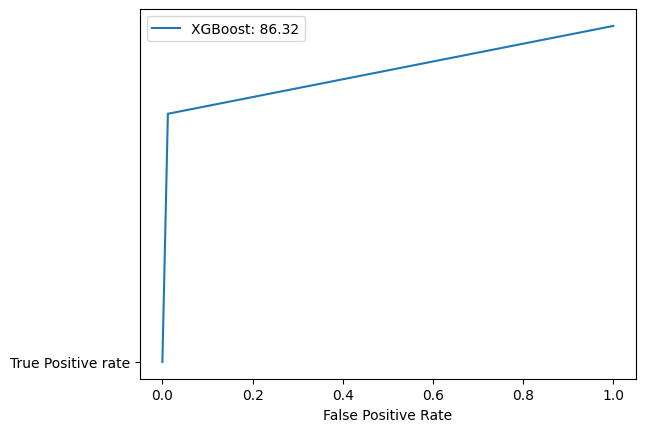

In [43]:
import matplotlib.pyplot as plt
plt.plot(fpr,tpr,label=f"XGBoost: {auc_scores*100:.2f}")
plt.xlabel("False Positive Rate")
plt.plot("True Positive rate")
plt.legend()

plt.show()

### AUC is also above 80%. We can finalise this model for deployment

In [44]:
import joblib
joblib.dump(best_xgboost,"model.joblib")
joblib.dump(pre,"pipeline.joblib")

['pipeline.joblib']